# La Liga 2025/26 Match Predictor — Walkthrough

End-to-end machine learning pipeline for predicting La Liga match results and scorelines.

**What this notebook covers:**
1. Data overview — 11 seasons, 4,100 matches
2. Feature engineering — ELO, form, shots, venue-specific stats
3. Model training — XGBoost classifier + Poisson regressors
4. Evaluation — walk-forward CV, calibration, confusion matrix
5. Predictions — score distributions for remaining fixtures

**Prerequisites:** run the pipeline first:
```bash
python data_engineering/build_model_dataset.py
python prediction/train_predict.py
```

In [1]:
import sys
sys.path.insert(0, 'prediction')

import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, accuracy_score

from train_predict import (
    FEATURES, XGB_PARAMS,
    add_season_progress, engineer_features,
    recency_weights, fit_imputer, apply_imputer,
    train_result_model, ranked_probability_score,
    poisson_score_probs, RESULT_TO_INT, INT_TO_RESULT,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


---
## 1. Data Overview

In [2]:
df = pd.read_csv('data/model_ready_matches_25_26.csv', encoding='utf-8-sig')
df['match_datetime'] = pd.to_datetime(df['match_datetime'], format='mixed')
df = df.sort_values('match_datetime').reset_index(drop=True)
df = add_season_progress(df)
df = engineer_features(df)

played = df[df['is_future_match'] == 0].copy()
future = df[df['is_future_match'] == 1].copy()

print(f'Total matches in dataset : {len(df)}')
print(f'  Played                 : {len(played)}')
print(f'  Future fixtures        : {len(future)}')
print(f'  Seasons                : {df["season"].nunique()}')
print(f'  Features               : {len(FEATURES)}')
print()
played.groupby('season').size().rename('matches').to_frame()

Total matches in dataset : 4180
  Played                 : 4100
  Future fixtures        : 80
  Seasons                : 11
  Features               : 55



,matches
season,
2015-16,380
2016-17,380
2017-18,380
2018-19,380
2019-20,380
2020-21,380
2021-22,380
2022-23,380
2023-24,380


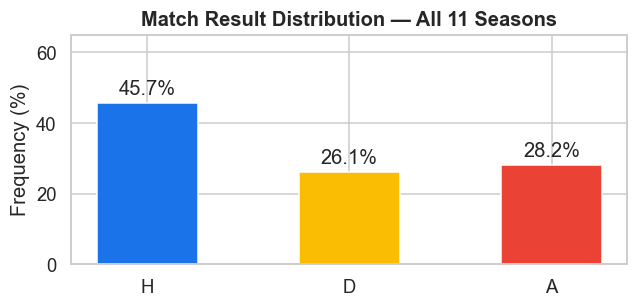

In [3]:
# Result distribution across all seasons
result_counts = played['target_ftr'].value_counts(normalize=True).reindex(['H','D','A'])

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(result_counts.index, result_counts.values * 100,
              color=['#1a73e8', '#fbbc04', '#ea4335'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('Frequency (%)')
ax.set_title('Match Result Distribution — All 11 Seasons', fontweight='bold')
ax.set_ylim(0, 65)
plt.tight_layout()

---
## 2. ELO Ratings — Team Strength Over Time

ELO is updated after every match: a win against a strong team raises your ELO more than a win against a weak one. It persists across seasons, giving a continuous measure of team quality.

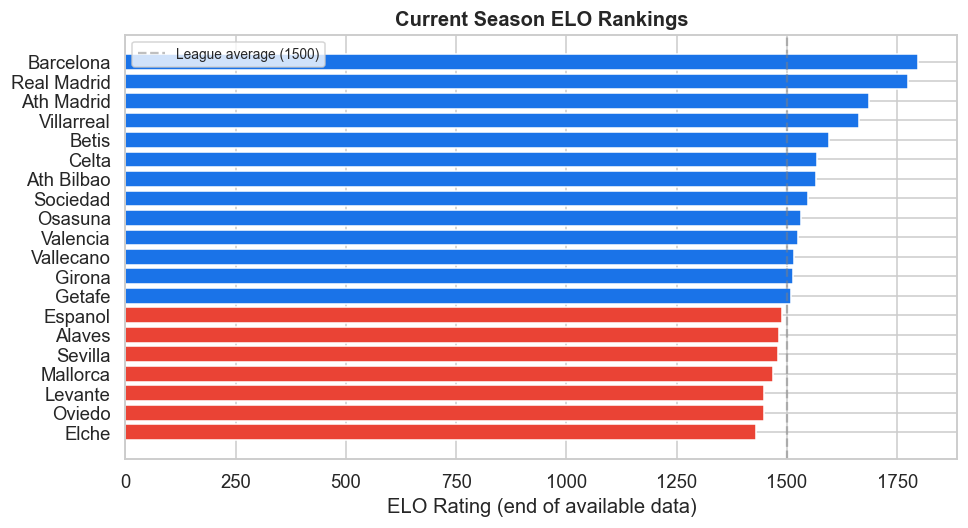

In [4]:
current = played[played['is_current_season'] == 1].copy()

# Final ELO per team this season
home_elo = current.groupby('home_team')['home_elo_pre'].last()
away_elo = current.groupby('away_team')['away_elo_pre'].last()
final_elo = home_elo.combine_first(away_elo).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colours = ['#1a73e8' if e >= 1500 else '#ea4335' for e in final_elo.values]
ax.barh(final_elo.index, final_elo.values, color=colours, edgecolor='white')
ax.axvline(1500, color='grey', linestyle='--', alpha=0.5, label='League average (1500)')
ax.set_xlabel('ELO Rating (end of available data)')
ax.set_title('Current Season ELO Rankings', fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()

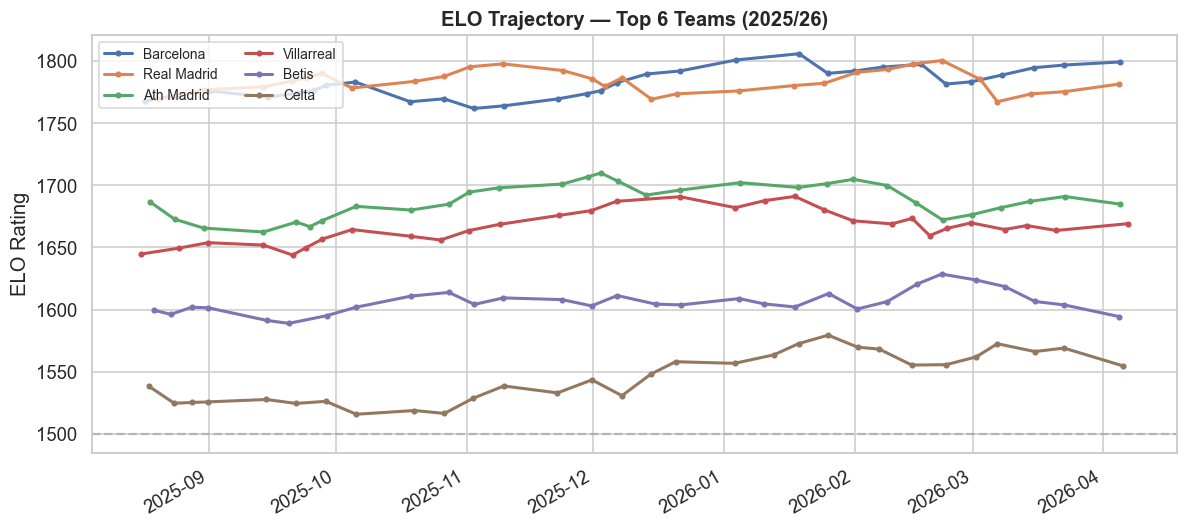

In [5]:
# ELO trajectory for top 6 teams
top6 = final_elo.head(6).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
for team in top6:
    h = current[current['home_team'] == team][['match_datetime','home_elo_pre']].rename(columns={'home_elo_pre':'elo'})
    a = current[current['away_team'] == team][['match_datetime','away_elo_pre']].rename(columns={'away_elo_pre':'elo'})
    traj = pd.concat([h, a]).sort_values('match_datetime')
    ax.plot(traj['match_datetime'], traj['elo'], marker='o', markersize=3, lw=2, label=team)

ax.axhline(1500, color='grey', linestyle='--', alpha=0.4)
ax.set_title('ELO Trajectory — Top 6 Teams (2025/26)', fontweight='bold')
ax.set_ylabel('ELO Rating')
ax.legend(loc='upper left', ncol=2, fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()

---
## 3. Feature Correlations

Which features have the strongest linear relationship with match outcome?

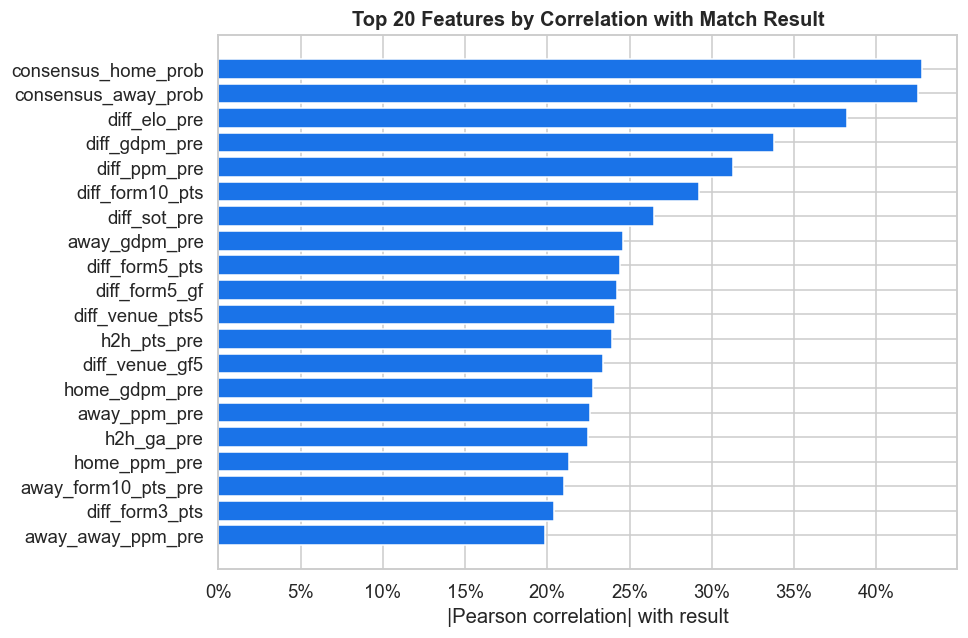

In [6]:
played2 = played.copy()
played2['result_int'] = played2['target_ftr'].map({'H': 1, 'D': 0, 'A': -1})

feat_corrs = (
    played2[FEATURES + ['result_int']]
    .corr()['result_int']
    .drop('result_int')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_corrs.index[::-1], feat_corrs.values[::-1], color='#1a73e8', edgecolor='white')
ax.set_xlabel('|Pearson correlation| with result')
ax.set_title('Top 20 Features by Correlation with Match Result', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()

---
## 4. Model Training & Evaluation

In [7]:
# Train / test split — same logic as production pipeline
hist    = played[played['is_current_season'] == 0].copy().reset_index(drop=True)
cur_split = int(len(current) * 0.83)
train = pd.concat([hist, current.iloc[:cur_split]], ignore_index=True).sort_values('match_datetime').reset_index(drop=True)
test  = current.iloc[cur_split:].copy().reset_index(drop=True)

medians = fit_imputer(train[FEATURES])
X_train = apply_imputer(train[FEATURES], medians)
X_test  = apply_imputer(test[FEATURES],  medians)
y_train = train['target_ftr'].map(RESULT_TO_INT).values
y_test  = test['target_ftr'].map(RESULT_TO_INT).values
w_train = recency_weights(len(train))

clf = train_result_model(X_train, y_train, X_test, y_test, w_train)
prob_test = clf.predict_proba(X_test)
pred_test = prob_test.argmax(axis=1)

acc  = accuracy_score(y_test, pred_test)
rps  = ranked_probability_score(y_test, prob_test)

odds = test[['avg_home_prob','avg_draw_prob','avg_away_prob']].fillna(1/3).values
odds_acc = accuracy_score(y_test, odds.argmax(axis=1))
odds_rps = ranked_probability_score(y_test, odds)

print(f'Train: {len(train)} matches   Test: {len(test)} matches')
print()
print(f'{"Metric":<30} {"Model":>10}  {"Odds baseline":>14}')
print(f'{"Accuracy":<30} {acc:>10.3f}  {odds_acc:>14.3f}')
print(f'{"RPS (lower=better)":<30} {rps:>10.4f}  {odds_rps:>14.4f}')

Train: 4049 matches   Test: 51 matches

Metric                              Model   Odds baseline
Accuracy                            0.529           0.510
RPS (lower=better)                 0.1960          0.2008


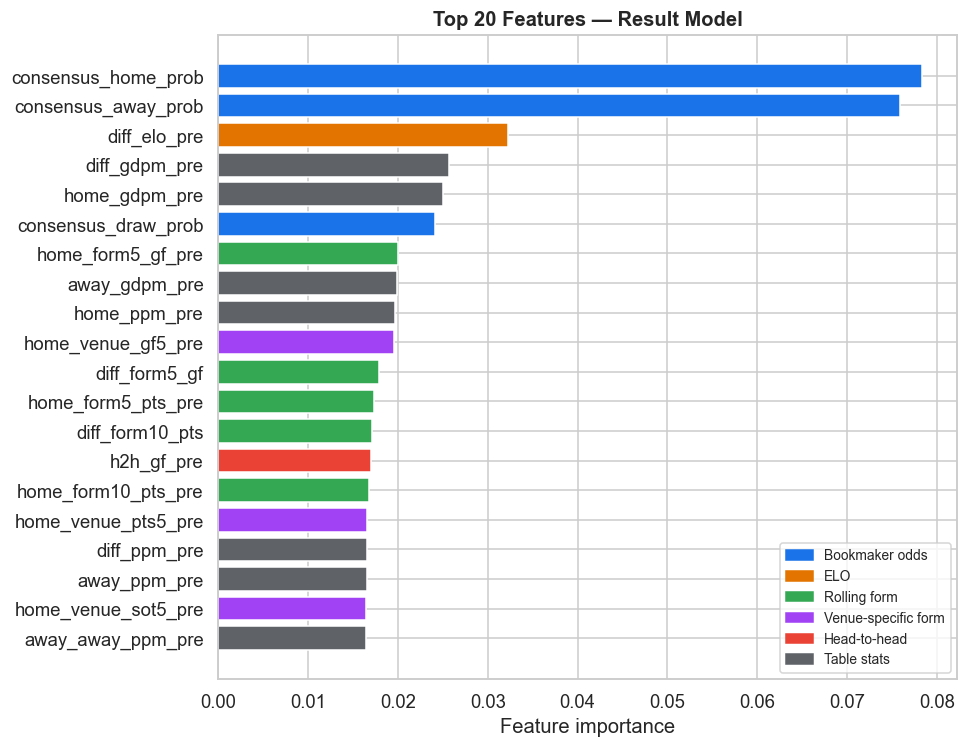

In [8]:
# Feature importance
fi = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()

def feat_colour(name):
    if 'prob' in name:   return '#1a73e8'
    if 'elo' in name:    return '#e37400'
    if 'form' in name:   return '#34a853'
    if 'venue' in name:  return '#a142f4'
    if 'h2h' in name:    return '#ea4335'
    return '#5f6368'

fi_top = fi.tail(20)
colours = [feat_colour(n) for n in fi_top.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_top.index, fi_top.values, color=colours, edgecolor='white')
ax.set_xlabel('Feature importance')
ax.set_title('Top 20 Features — Result Model', fontweight='bold')

from matplotlib.patches import Patch
legend_items = [
    Patch(color='#1a73e8', label='Bookmaker odds'),
    Patch(color='#e37400', label='ELO'),
    Patch(color='#34a853', label='Rolling form'),
    Patch(color='#a142f4', label='Venue-specific form'),
    Patch(color='#ea4335', label='Head-to-head'),
    Patch(color='#5f6368', label='Table stats'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
plt.tight_layout()

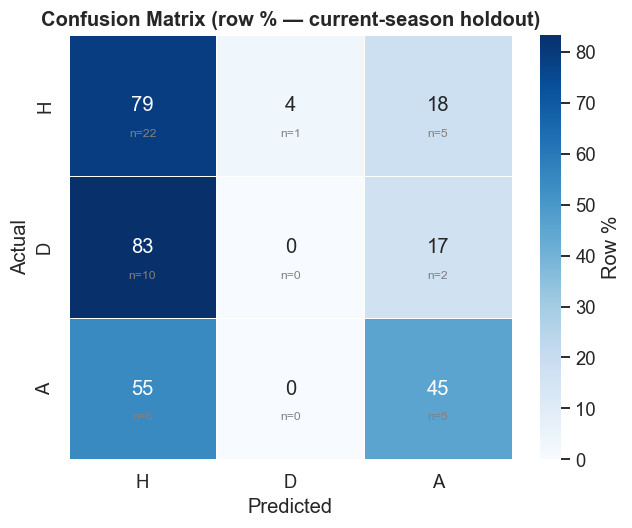

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_test)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['H','D','A'], yticklabels=['H','D','A'],
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Row %'}, ax=ax)
for i in range(3):
    for j in range(3):
        ax.text(j+0.5, i+0.72, f'n={cm[i,j]}', ha='center', fontsize=8, color='grey')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (row % — current-season holdout)', fontweight='bold')
plt.tight_layout()

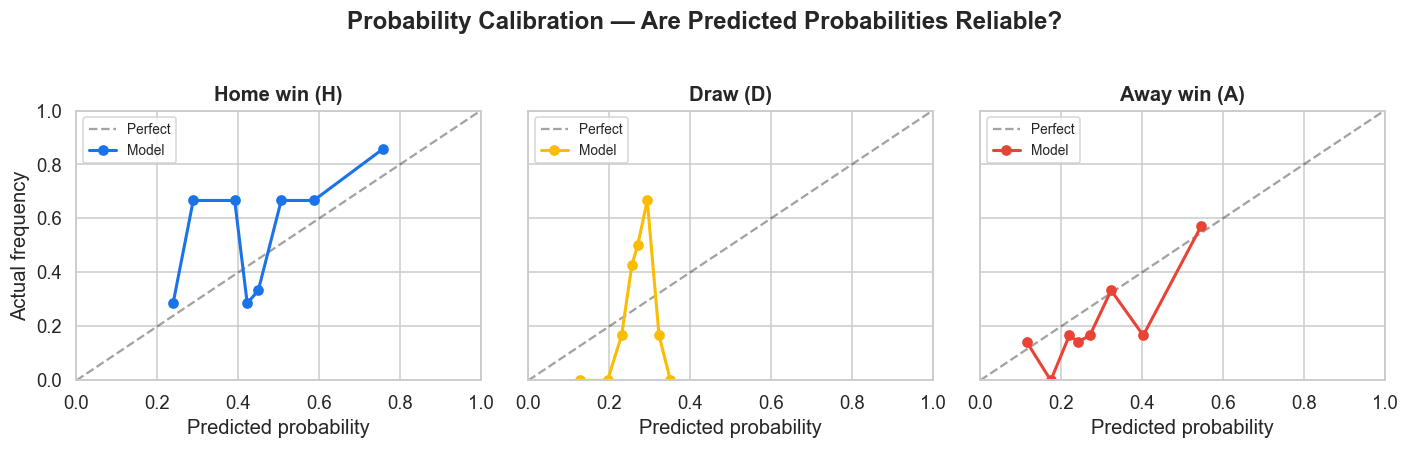

In [10]:
# Calibration curves — are the probabilities reliable?
labels = ['Home win (H)', 'Draw (D)', 'Away win (A)']
colours = ['#1a73e8', '#fbbc04', '#ea4335']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i, (label, colour, ax) in enumerate(zip(labels, colours, axes)):
    y_bin = (y_test == i).astype(int)
    try:
        frac, mean_p = calibration_curve(y_bin, prob_test[:, i], n_bins=8, strategy='quantile')
        ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
        ax.plot(mean_p, frac, 'o-', color=colour, lw=2, label='Model')
    except ValueError:
        pass
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Predicted probability')
    if i == 0: ax.set_ylabel('Actual frequency')
    ax.legend(fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

fig.suptitle('Probability Calibration — Are Predicted Probabilities Reliable?', fontweight='bold', y=1.02)
plt.tight_layout()

---
## 5. Predictions for Remaining Fixtures

In [11]:
preds = pd.read_csv('data/predictions_future_matches.csv', encoding='utf-8-sig')
preds['match_datetime'] = pd.to_datetime(preds['match_datetime'], format='mixed')
print(f'{len(preds)} remaining fixtures')
preds[['match_datetime','home_team','away_team',
       'predicted_result','prob_home_win','prob_draw','prob_away_win',
       'most_likely_score','confidence','confidence_tier']].head(15)

80 remaining fixtures


,match_datetime,home_team,away_team,predicted_result,prob_home_win,prob_draw,prob_away_win,most_likely_score,confidence,confidence_tier
0,2026-04-12 19:00:00,Ath Bilbao,Villarreal,H,0.507,0.245,0.248,1-1,0.507,Medium
1,2026-04-12 19:00:00,Barcelona,Espanol,H,0.561,0.220,0.218,1-1,0.561,High
2,2026-04-12 19:00:00,Celta,Oviedo,H,0.473,0.317,0.210,1-1,0.473,Medium
3,2026-04-12 19:00:00,Elche,Valencia,H,0.456,0.305,0.239,1-1,0.456,Medium
4,2026-04-12 19:00:00,Levante,Getafe,H,0.501,0.270,0.229,1-1,0.501,Medium
5,2026-04-12 19:00:00,Mallorca,Vallecano,H,0.487,0.278,0.235,1-1,0.487,Medium
6,2026-04-12 19:00:00,Osasuna,Betis,H,0.515,0.249,0.236,1-1,0.515,Medium
7,2026-04-12 19:00:00,Real Madrid,Girona,H,0.556,0.172,0.272,1-1,0.556,High
8,2026-04-12 19:00:00,Sevilla,Ath Madrid,H,0.519,0.280,0.202,1-1,0.519,Medium
9,2026-04-12 19:00:00,Sociedad,Alaves,H,0.473,0.317,0.210,1-1,0.473,Medium


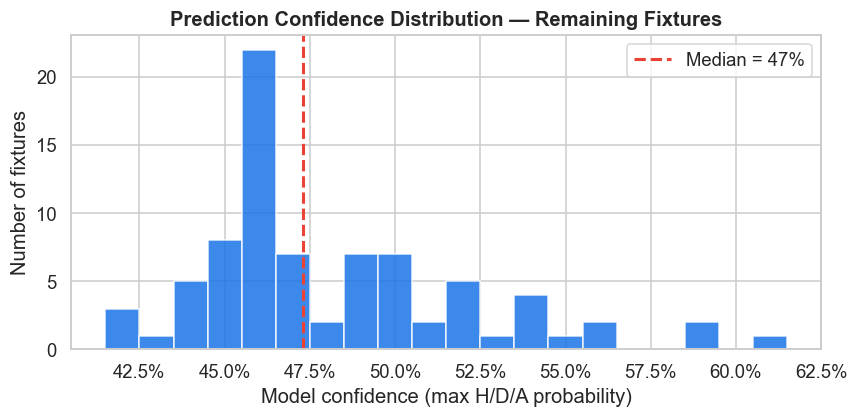

In [12]:
# Confidence distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(preds['confidence'], bins=20, color='#1a73e8', edgecolor='white', alpha=0.85)
ax.axvline(preds['confidence'].median(), color='#ea4335', linestyle='--', lw=2,
           label=f'Median = {preds["confidence"].median():.0%}')
ax.set_xlabel('Model confidence (max H/D/A probability)')
ax.set_ylabel('Number of fixtures')
ax.set_title('Prediction Confidence Distribution — Remaining Fixtures', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()


Fixture: Real Madrid vs Girona
Predicted: H  (56% confidence)
Score probabilities: 1-1 (12%)  |  1-0 (10%)  |  2-1 (10%)  |  2-0 (8%)  |  0-1 (7%)


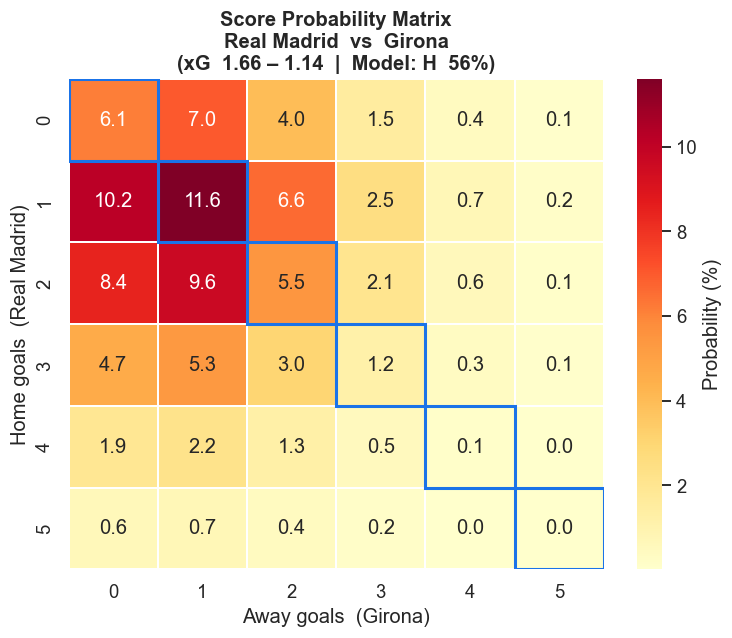

In [13]:
# Score probability heatmap for a specific fixture
# Change the index to explore different fixtures
FIXTURE_IDX = 7  # e.g. Real Madrid vs Girona

row = preds.iloc[FIXTURE_IDX]
lam_h, lam_a = row['xg_home'], row['xg_away']
n = 6

def pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)

grid = np.array([[pmf(h, lam_h) * pmf(a, lam_a) for a in range(n)] for h in range(n)])
grid /= grid.sum()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(grid * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=range(n), yticklabels=range(n),
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Probability (%)'}, ax=ax)
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#1a73e8', lw=2))
ax.set_xlabel(f"Away goals  ({row['away_team']})")
ax.set_ylabel(f"Home goals  ({row['home_team']})")
ax.set_title(f"Score Probability Matrix\n{row['home_team']}  vs  {row['away_team']}\n"
             f"(xG  {lam_h:.2f} – {lam_a:.2f}  |  Model: {row['predicted_result']}  {row['confidence']:.0%})",
             fontweight='bold')
plt.tight_layout()

print(f"\nFixture: {row['home_team']} vs {row['away_team']}")
print(f"Predicted: {row['predicted_result']}  ({row['confidence']:.0%} confidence)")
print(f"Score probabilities: {row['score_probabilities']}")

In [14]:
# High-confidence predictions only
high_conf = preds[preds['confidence'] >= 0.55].sort_values('confidence', ascending=False)
print(f'{len(high_conf)} fixtures with confidence >= 55%')
high_conf[['match_datetime','home_team','away_team',
            'predicted_result','prob_home_win','prob_draw','prob_away_win',
            'most_likely_score','confidence']]

5 fixtures with confidence >= 55%


,match_datetime,home_team,away_team,predicted_result,prob_home_win,prob_draw,prob_away_win,most_likely_score,confidence
66,2026-05-17 19:00:00,Barcelona,Betis,H,0.615,0.171,0.215,1-1,0.615
27,2026-04-22 19:00:00,Real Madrid,Alaves,H,0.591,0.165,0.244,1-1,0.591
21,2026-04-22 19:00:00,Barcelona,Celta,H,0.591,0.165,0.244,1-1,0.591
1,2026-04-12 19:00:00,Barcelona,Espanol,H,0.561,0.220,0.218,1-1,0.561
7,2026-04-12 19:00:00,Real Madrid,Girona,H,0.556,0.172,0.272,1-1,0.556


---
## 6. Limitations & Next Steps

### Why the model agrees with bookmaker odds on almost every fixture

All the features we engineer — ELO, form, shots, H2H — are a **subset of what professional oddsmakers already price in**. Bet365 employs analysts tracking injuries, tactical changes, and market movements in real time. Our `consensus_home_prob` and `consensus_away_prob` features effectively let the model inherit all of that knowledge.

**To generate genuine disagreements with the market**, you would need:
- **Live odds movement** — if a line moves from 2.0 to 2.4 in the 48 hours before kickoff, sharp money has spotted something (injury news, rotation). Scraping live odds would surface these discrepancies.
- **Injury/suspension data** — a team missing its top striker changes the goal model significantly. APIs like Opta or SofaScore provide this.
- **Squad rotation context** — teams in Champions League often rest starters before big European games. This is publicly known but not in our dataset.

### The draw problem

Draws (≈26% of matches) have near-zero predictive signal — the bookmaker draw probability only differs by ~1.7pp between matches that end in a draw and those that don't. This is a fundamental property of football, not a model deficiency. The theoretical accuracy ceiling for any model is approximately **55–57%**.

### Updating the model each gameweek

```bash
# 1. Add new results to data/SP1 2025 updated.csv
# 2. Remove played matches from data/fixtures_25_26.csv
# 3. Rebuild and retrain:
python data_engineering/build_model_dataset.py
python prediction/train_predict.py
python visualise.py  # refresh charts
```